In [85]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go 
import plotly.io as pio 
import matplotlib.dates as mdates
from sklearn.preprocessing import LabelEncoder


In [67]:
df = pd.read_csv('data/filtered_data_SEARO_1769008875181.csv')
df.head()



/tmp/ipykernel_12437/2142181273.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/filtered_data_SEARO_1769008875181.csv')


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID,region
0,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,2015-12-01,2015-12-31,2015,75,Confirmed,Admin0,Month,MOH-BGD-20002021-Y01-01,SEARO
1,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,2017-09-01,2017-09-30,2017,430,Confirmed,Admin0,Month,MOH-BGD-20002021-Y01-01,SEARO
2,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,2016-03-01,2016-03-31,2016,17,Confirmed,Admin0,Month,MOH-BGD-20002021-Y01-01,SEARO
3,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,2016-04-01,2016-04-30,2016,38,Confirmed,Admin0,Month,MOH-BGD-20002021-Y01-01,SEARO
4,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,2016-01-01,2016-01-31,2016,13,Confirmed,Admin0,Month,MOH-BGD-20002021-Y01-01,SEARO


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41997 entries, 0 to 41996
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   adm_0_name                    41997 non-null  object 
 1   adm_1_name                    39799 non-null  object 
 2   adm_2_name                    2802 non-null   object 
 3   full_name                     41997 non-null  object 
 4   ISO_A0                        41997 non-null  object 
 5   FAO_GAUL_code                 41997 non-null  int64  
 6   RNE_iso_code                  41997 non-null  object 
 7   IBGE_code                     0 non-null      float64
 8   calendar_start_date           41997 non-null  object 
 9   calendar_end_date             41997 non-null  object 
 10  Year                          41997 non-null  int64  
 11  dengue_total                  41997 non-null  int64  
 12  case_definition_standardised  41997 non-null  object 
 13  S

In [69]:
df.describe()

,FAO_GAUL_code,IBGE_code,Year,dengue_total
count,4.199700e+04,0.0,41997.000000,41997.000000
mean,2.128313e+05,NaN,2010.269329,431.791342
std,4.081484e+05,NaN,9.098686,3324.628277
min,2.300000e+01,NaN,1958.000000,0.000000
25%,2.871000e+03,NaN,2003.000000,6.000000
50%,2.901000e+03,NaN,2011.000000,24.000000
75%,2.235700e+04,NaN,2018.000000,98.000000
max,1.013696e+06,NaN,2025.000000,174285.000000


In [70]:
country = df['adm_0_name'].unique()
print(f"Unique values of adm_0_name: {country}")

iso_code = df['ISO_A0'].unique()
print(f"Unique values of ISO_A0: {iso_code}")

dengue_total = df['dengue_total'].unique()
print(f"Unique values of dengue_total: {dengue_total}")
print(f"Shape of dengue_total: {dengue_total.shape}")

# total number of cases
total_cases = df['dengue_total'].sum()
print(f"Total number of cases: {total_cases}")

# total number of cases by country
total_cases_by_country = df.groupby('adm_0_name')['dengue_total'].sum()
print(f"Total number of cases by country: {total_cases_by_country}")





Unique values of adm_0_name: ['BANGLADESH' 'BHUTAN' 'INDIA' 'INDONESIA' 'MALDIVES' 'MYANMAR' 'NEPAL'
 'SRI LANKA' 'THAILAND' 'TIMOR-LESTE']
Unique values of ISO_A0: ['BGD' 'BTN' 'IND' 'IDN' 'MDV' 'MMR' 'NPL' 'LKA' 'THA' 'TLS']
Unique values of dengue_total: [  75  430   17 ... 2447 1128 1201]
Shape of dengue_total: (2817,)
Total number of cases: 18133941
Total number of cases by country: adm_0_name
BANGLADESH      672026
BHUTAN           18937
INDIA          2275276
INDONESIA      8359239
MALDIVES         45123
MYANMAR         634947
NEPAL           276657
SRI LANKA      1352147
THAILAND       4479008
TIMOR-LESTE      20581
Name: dengue_total, dtype: int64


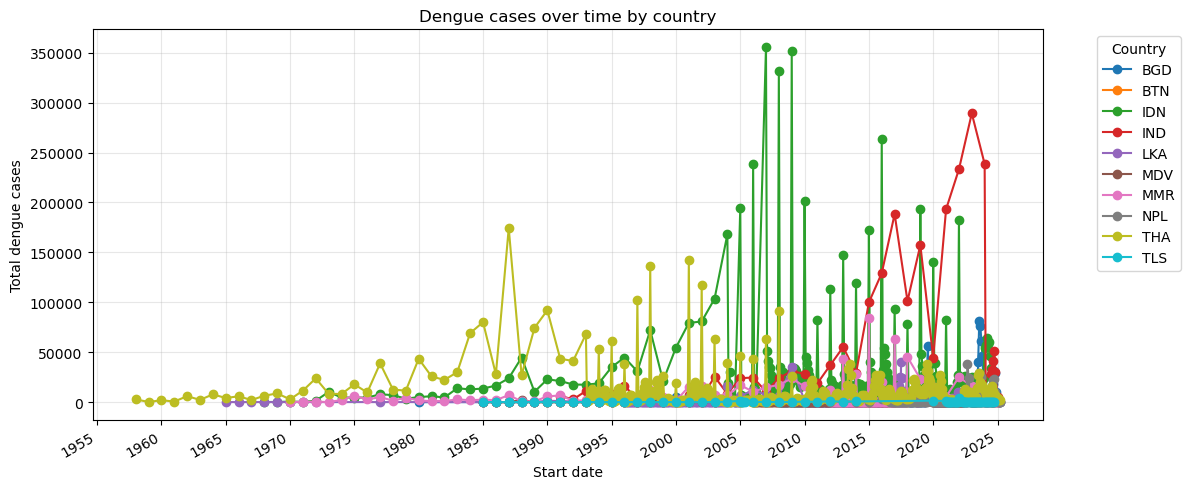

In [71]:
# need to plot each country's total cases by start date to end date 

fig, ax = plt.subplots(figsize=(12, 5))
for country, g in agg.groupby('ISO_A0'):
    ax.plot(g['calendar_start_date'], g['dengue_total'], marker='o', label=country)

# set x-axis ticks every 5 years
ax.xaxis.set_major_locator(mdates.YearLocator(5))      # 5-year step: 1960, 1965, 1970, ...
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlabel('Start date')
ax.set_ylabel('Total dengue cases')
ax.set_title('Dengue cases over time by country')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [72]:
# ensure datetime
df['calendar_start_date'] = pd.to_datetime(df['calendar_start_date'])

# sort by country and time (important for forecasting & lag features)
df = df.sort_values(['ISO_A0', 'calendar_start_date'])

# extract time features
df['year'] = df['calendar_start_date'].dt.year
df['month'] = df['calendar_start_date'].dt.month
df['dayofyear'] = df['calendar_start_date'].dt.dayofyear
df['weekofyear'] = df['calendar_start_date'].dt.isocalendar().week.astype(int)

# OPTIONAL: add simple lag features per country (previous month’s cases, etc.)
df['lag_1'] = df.groupby('ISO_A0')['dengue_total'].shift(1)
df['lag_2'] = df.groupby('ISO_A0')['dengue_total'].shift(2)
df['lag_3'] = df.groupby('ISO_A0')['dengue_total'].shift(3)

# keep only useful columns for time-forecasting
feature_cols = [
    'ISO_A0',           # country
    'year',
    'month',
    'dayofyear',
    'weekofyear',
    'lag_1',
    'lag_2',
    'lag_3'
]
target_col = 'dengue_total'

df_features = df[feature_cols + [target_col]].dropna()  # drop rows where lags are NaN
df_features.head()

,ISO_A0,year,month,dayofyear,weekofyear,lag_1,lag_2,lag_3,dengue_total
30,BGD,1987,1,1,1,0.0,0.0,4.0,0
31,BGD,1988,1,1,53,0.0,0.0,0.0,0
32,BGD,1989,1,1,52,0.0,0.0,0.0,0
46,BGD,1990,1,1,1,0.0,0.0,0.0,0
47,BGD,1991,1,1,1,0.0,0.0,0.0,0


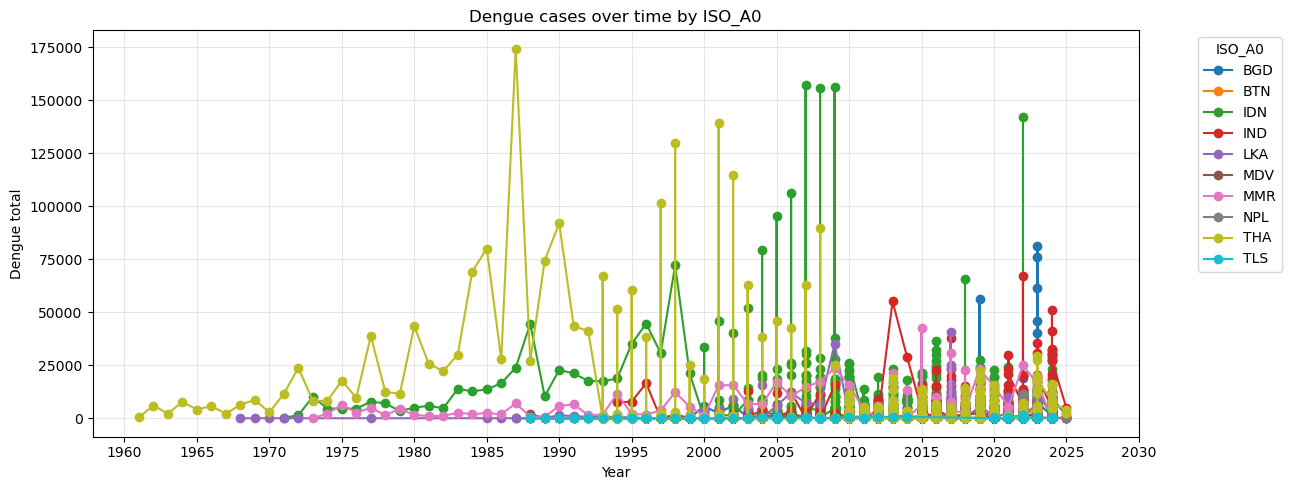

In [73]:
fig, ax = plt.subplots(figsize=(13, 5))

for country, g in df_features.groupby('ISO_A0'):
    g = g.sort_values('year')
    ax.plot(g['year'], g['dengue_total'], marker='o', label=country)

# set x-axis ticks every 5 years
min_year = df_features['year'].min()
max_year = df_features['year'].max()
# round down to nearest 5-year mark
start_year = (min_year // 5) * 5
# round up to nearest 5-year mark
end_year = ((max_year // 5) + 1) * 5
ax.set_xticks(range(start_year, end_year + 1, 5))

ax.set_xlabel('Year')
ax.set_ylabel('Dengue total')
ax.set_title('Dengue cases over time by ISO_A0')
ax.legend(title='ISO_A0', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
import pandas as pd
import requests
import time

def fetch_nasa_power_monthly(lat, lon, start_year, end_year):
    """
    Fetch monthly temperature and precipitation from NASA POWER API (FREE)
    Earliest data: 1981
    """
    start_year = max(1981, start_year)  # clamp to earliest available
    
    url = (
        "https://power.larc.nasa.gov/api/temporal/monthly/point"
        f"?parameters=T2M,PRECTOTCORR&community=RE"
        f"&longitude={lon}&latitude={lat}"
        f"&start={start_year}&end={end_year}&format=JSON"
    )
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    j = r.json()
    
    # Parse response structure: j['properties']['parameter'][param][YYYYMM] = value
    p = j.get('properties', {}).get('parameter', {})
    
    if not isinstance(p, dict):
        raise ValueError(f"Unexpected API response format: 'parameter' is not a dict")
    
    records = []
    
    # Check if T2M and PRECTOTCORR exist and are dicts
    if 'T2M' not in p:
        raise ValueError(f"Missing T2M in response. Available params: {list(p.keys())}")
    
    # Use PRECTOTCORR (corrected precipitation) instead of PRECTOT
    precip_key = 'PRECTOTCORR' if 'PRECTOTCORR' in p else 'PRECTOT'
    if precip_key not in p:
        raise ValueError(f"Missing precipitation data. Available params: {list(p.keys())}")
    
    t2m_data = p['T2M']
    pr_data = p[precip_key]
    
    if not isinstance(t2m_data, dict) or not isinstance(pr_data, dict):
        raise ValueError(f"T2M or {precip_key} is not a dict. T2M type: {type(t2m_data)}, PR type: {type(pr_data)}")
    
    # Parse dates in YYYYMM format (e.g., '198101' = 1981, month 1)
    for date_str, temp_val in t2m_data.items():
        if len(date_str) != 6:
            continue  # skip invalid date strings
        
        year = int(date_str[:4])
        month = int(date_str[4:6])
        
        # Get corresponding precipitation value
        precip_val = pr_data.get(date_str)
        
        if precip_val is not None:
            records.append({
                'year': year,
                'month': month,
                'temperature_c': temp_val,  # Celsius
                'precipitation_mm': precip_val  # mm/day
            })
    
    if not records:
        raise ValueError("No records extracted from API response")
    
    return pd.DataFrame(records)

def add_weather_to_dataframe(df, country_col='ISO_A0', date_col='calendar_start_date'):
    """
    Add weather data to your dengue dataframe
    """
    # Create a copy to avoid modifying original
    cpy_df = df.copy()
    
    # Parse dates
    cpy_df[date_col] = pd.to_datetime(cpy_df[date_col])
    cpy_df['year'] = cpy_df[date_col].dt.year
    cpy_df['month'] = cpy_df[date_col].dt.month
    
    # Country ISO3 -> (lat, lon) mapping (add all your countries)
    iso_to_latlon = {
        'BGD': (23.6850, 90.3563),  # Bangladesh
        'THA': (15.8700, 100.9925),  # Thailand
        'IDN': (-0.7893, 113.9213),  # Indonesia
        'IND': (20.5937, 78.9629),   # India
        'LKA': (7.8731, 80.7718),    # Sri Lanka
        'MMR': (21.9162, 95.9560),   # Myanmar
        'NPL': (28.3949, 84.1240),   # Nepal
        'MDV': (3.2028, 73.2207),    # Maldives
        'TLS': (-8.8742, 125.7275),  # Timor-Leste
        'BTN': (27.5142, 90.4336),   # Bhutan
    }
    
    # Get date range
    start_year = max(1981, int(cpy_df['year'].min()))
    end_year = int(cpy_df['year'].max())
    
    # Fetch weather for each country
    weather_rows = []
    countries = cpy_df[country_col].unique()
    
    for iso in countries:
        if iso not in iso_to_latlon:
            print(f"⚠️  Skipping {iso}: no lat/lon mapping")
            continue
        
        lat, lon = iso_to_latlon[iso]
        try:
            print(f"📡 Fetching weather for {iso} ({lat}, {lon})...")
            weather_df = fetch_nasa_power_monthly(lat, lon, start_year, end_year)
            weather_df[country_col] = iso
            weather_rows.append(weather_df)
            print(f"   ✓ Got {len(weather_df)} months")
        except Exception as e:
            print(f"   ✗ Error: {e}")
            import traceback
            traceback.print_exc()  # print full traceback for debugging
            continue
        
        time.sleep(0.5)  # be polite to API
    
    if not weather_rows:
        print("⚠️  No weather data fetched. Returning original dataframe.")
        return cpy_df
    
    weather_all = pd.concat(weather_rows, ignore_index=True)
    
    # Merge weather with dengue data
    merged = cpy_df.merge(
        weather_all,
        on=[country_col, 'year', 'month'],
        how='left'
    )
    
    print(f"\n✅ Merged complete!")
    print(f"   Original rows: {len(cpy_df)}")
    print(f"   Merged rows: {len(merged)}")
    print(f"   Missing weather: {merged[['temperature_c','precipitation_mm']].isna().sum().sum()} cells")
    
    return merged

# Usage example:
cpy_df = df.copy()  # if you haven't already
df_with_weather = add_weather_to_dataframe(df, country_col='ISO_A0', date_col='calendar_start_date')

📡 Fetching weather for BGD (23.685, 90.3563)...
   ✓ Got 585 months
📡 Fetching weather for BTN (27.5142, 90.4336)...
   ✓ Got 585 months
📡 Fetching weather for IDN (-0.7893, 113.9213)...
   ✓ Got 585 months
📡 Fetching weather for IND (20.5937, 78.9629)...
   ✓ Got 585 months
📡 Fetching weather for LKA (7.8731, 80.7718)...
   ✓ Got 585 months
📡 Fetching weather for MDV (3.2028, 73.2207)...
   ✓ Got 585 months
📡 Fetching weather for MMR (21.9162, 95.956)...
   ✓ Got 585 months
📡 Fetching weather for NPL (28.3949, 84.124)...
   ✓ Got 585 months
📡 Fetching weather for THA (15.87, 100.9925)...
   ✓ Got 585 months
📡 Fetching weather for TLS (-8.8742, 125.7275)...
   ✓ Got 585 months

✅ Merged complete!
   Original rows: 41997
   Merged rows: 41997
   Missing weather: 114 cells


In [80]:
# Save merged data to CSV
# df_with_weather.to_csv('data/merged_data.csv', index=False)
# print(f"✅ Saved merged data to data/merged_data.csv")
# print(f"   Total rows: {len(df_with_weather)}")
# print(f"   Columns: {df_with_weather.columns.tolist()}")

In [81]:
df_merge = pd.read_csv('data/merged_data.csv')
df_merge.head()

/tmp/ipykernel_12437/1035224579.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merge = pd.read_csv('data/merged_data.csv')


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,...,region,year,month,dayofyear,weekofyear,lag_1,lag_2,lag_3,temperature_c,precipitation_mm
0,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,1980-01-01,1980-12-31,...,SEARO,1980,1,1,1,NaN,NaN,NaN,NaN,NaN
1,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,1985-01-01,1985-12-31,...,SEARO,1985,1,1,1,4.0,NaN,NaN,20.21,0.19
2,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,1986-01-01,1986-12-31,...,SEARO,1986,1,1,1,0.0,4.0,NaN,19.42,0.08
3,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,1987-01-01,1987-12-31,...,SEARO,1987,1,1,1,0.0,0.0,4.0,18.49,0.01
4,BANGLADESH,NaN,NaN,BANGLADESH,BGD,23,BGD,NaN,1988-01-01,1988-12-31,...,SEARO,1988,1,1,53,0.0,0.0,0.0,20.73,0.00


In [82]:
# all column names
df_merge.columns

Index(['adm_0_name', 'adm_1_name', 'adm_2_name', 'full_name', 'ISO_A0',
       'FAO_GAUL_code', 'RNE_iso_code', 'IBGE_code', 'calendar_start_date',
       'calendar_end_date', 'Year', 'dengue_total',
       'case_definition_standardised', 'S_res', 'T_res', 'UUID', 'region',
       'year', 'month', 'dayofyear', 'weekofyear', 'lag_1', 'lag_2', 'lag_3',
       'temperature_c', 'precipitation_mm'],
      dtype='object')

In [83]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41997 entries, 0 to 41996
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   adm_0_name                    41997 non-null  object 
 1   adm_1_name                    39799 non-null  object 
 2   adm_2_name                    2802 non-null   object 
 3   full_name                     41997 non-null  object 
 4   ISO_A0                        41997 non-null  object 
 5   FAO_GAUL_code                 41997 non-null  int64  
 6   RNE_iso_code                  41997 non-null  object 
 7   IBGE_code                     0 non-null      float64
 8   calendar_start_date           41997 non-null  object 
 9   calendar_end_date             41997 non-null  object 
 10  Year                          41997 non-null  int64  
 11  dengue_total                  41997 non-null  int64  
 12  case_definition_standardised  41997 non-null  object 
 13  S

In [86]:

# Convert date columns to datetime
df_merge['calendar_start_date'] = pd.to_datetime(df_merge['calendar_start_date'])
df_merge['calendar_end_date'] = pd.to_datetime(df_merge['calendar_end_date'])

# Sort by country and date (important for lag features)
df_merge = df_merge.sort_values(['ISO_A0', 'calendar_start_date']).reset_index(drop=True)

# ===== FEATURE EXTRACTION FOR TIME SERIES =====

# 1. Time-based features (cyclical encoding for seasonality)
df_merge['month_sin'] = np.sin(2 * np.pi * df_merge['month'] / 12)
df_merge['month_cos'] = np.cos(2 * np.pi * df_merge['month'] / 12)
df_merge['dayofyear_sin'] = np.sin(2 * np.pi * df_merge['dayofyear'] / 365)
df_merge['dayofyear_cos'] = np.cos(2 * np.pi * df_merge['dayofyear'] / 365)

# 2. Season/Quarter encoding
df_merge['quarter'] = df_merge['month'].apply(lambda x: (x-1)//3 + 1)
df_merge['is_rainy_season'] = df_merge['month'].isin([6, 7, 8, 9, 10]).astype(int)  # adjust for your region

# 3. Lag features (if not already present or need more)
for lag in [1, 2, 3, 6, 12]:  # 1, 2, 3 months, 6 months, 1 year
    df_merge[f'dengue_lag_{lag}'] = df_merge.groupby('ISO_A0')['dengue_total'].shift(lag)

# 4. Rolling statistics (moving averages)
for window in [3, 6, 12]:  # 3-month, 6-month, 12-month averages
    df_merge[f'dengue_ma_{window}'] = df_merge.groupby('ISO_A0')['dengue_total'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_merge[f'dengue_std_{window}'] = df_merge.groupby('ISO_A0')['dengue_total'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

# 5. Weather lag features (weather affects dengue with delay)
for lag in [1, 2, 3]:
    df_merge[f'temp_lag_{lag}'] = df_merge.groupby('ISO_A0')['temperature_c'].shift(lag)
    df_merge[f'precip_lag_{lag}'] = df_merge.groupby('ISO_A0')['precipitation_mm'].shift(lag)

# 6. Rolling weather statistics
for window in [3, 6]:
    df_merge[f'temp_ma_{window}'] = df_merge.groupby('ISO_A0')['temperature_c'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_merge[f'precip_ma_{window}'] = df_merge.groupby('ISO_A0')['precipitation_mm'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

# 7. Year-over-year change (if you have multi-year data)
df_merge['dengue_yoy'] = df_merge.groupby(['ISO_A0', 'month'])['dengue_total'].transform(
    lambda x: x.pct_change(periods=12)  # compare same month last year
)

# 8. Encode country (categorical)
le_country = LabelEncoder()
df_merge['ISO_A0_encoded'] = le_country.fit_transform(df_merge['ISO_A0'])

# 9. Time since start (trend feature)
df_merge['time_index'] = df_merge.groupby('ISO_A0').cumcount() + 1

# 10. Extract year as feature (for trend)
df_merge['year_normalized'] = (df_merge['year'] - df_merge['year'].min()) / (df_merge['year'].max() - df_merge['year'].min())

# ===== SELECT FEATURES FOR MODELING =====

# Drop redundant/unnecessary columns
cols_to_drop = [
    'adm_0_name', 'adm_1_name', 'adm_2_name', 'full_name',  # redundant with ISO_A0
    'FAO_GAUL_code', 'RNE_iso_code', 'IBGE_code',  # ID codes
    'calendar_end_date', 'Year',  # redundant with year/month
    'case_definition_standardised', 'S_res', 'T_res', 'UUID', 'region',  # metadata
    'lag_1', 'lag_2', 'lag_3',  # if you want to use the new lag features instead
]

feature_cols = [
    # Time features
    'year', 'month', 'quarter', 'dayofyear', 'weekofyear',
    'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos',
    'is_rainy_season', 'year_normalized', 'time_index',
    
    # Location
    'ISO_A0_encoded',
    
    # Lag features
    'dengue_lag_1', 'dengue_lag_2', 'dengue_lag_3', 'dengue_lag_6', 'dengue_lag_12',
    
    # Rolling statistics
    'dengue_ma_3', 'dengue_ma_6', 'dengue_ma_12',
    'dengue_std_3', 'dengue_std_6', 'dengue_std_12',
    
    # Weather features
    'temperature_c', 'precipitation_mm',
    'temp_lag_1', 'temp_lag_2', 'temp_lag_3',
    'precip_lag_1', 'precip_lag_2', 'precip_lag_3',
    'temp_ma_3', 'temp_ma_6',
    'precip_ma_3', 'precip_ma_6',
    
    # Year-over-year
    'dengue_yoy',
]

# Create feature dataframe
df_features = df_merge[feature_cols + ['dengue_total']].copy()

# Drop rows with NaN (from lag features at the beginning)
df_features = df_features.dropna().reset_index(drop=True)

print(f"✅ Feature extraction complete!")
print(f"   Original rows: {len(df_merge)}")
print(f"   Feature rows: {len(df_features)}")
print(f"   Features: {len(feature_cols)}")
print(f"\nFeature columns:")
print(df_features[feature_cols].head())
print(f"\nMissing values:")
print(df_features[feature_cols].isna().sum())

✅ Feature extraction complete!
   Original rows: 41997
   Feature rows: 39989
   Features: 37

Feature columns:
   year  month  quarter  dayofyear  weekofyear  month_sin  month_cos  \
0  1996      1        1          1           1        0.5   0.866025   
1  1999      1        1          1          53        0.5   0.866025   
2  2000      1        1          1          52        0.5   0.866025   
3  2001      1        1          1           1        0.5   0.866025   
4  2002      1        1          1           1        0.5   0.866025   

   dayofyear_sin  dayofyear_cos  is_rainy_season  ...  temp_lag_2  temp_lag_3  \
0       0.017213       0.999852                0  ...       20.45       19.80   
1       0.017213       0.999852                0  ...       19.03       19.49   
2       0.017213       0.999852                0  ...       17.91       19.03   
3       0.017213       0.999852                0  ...       17.97       17.91   
4       0.017213       0.999852                0  